# Testing our equation to Flume data

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error

### Model Functions

τ*c evolution - transport capacity (tc)

In [6]:
def evolve_tauc_tc(
    tau_star,           # array of Shields stress τ*(t)
    dt,                 # timestep between τ* samples (15 minutes in my case)
    tau_c_min,          # minimum τ*c global
    tau_c_max,          # maximum τ*c global
    event_indices,      # time labels or integer positions where τ*c observations are available
    tau_c_obs,          # observed τ*c values at event_indices
    A = 0.2924,
    B = 8.6866,
    multiplicative_factor=1  # factor to adjust k values 
):

    # convert τ* to numeric 1D array and keep index if Series
    if isinstance(tau_star, pd.Series):
        tau_index = tau_star.index
        tau_star_vals = tau_star.to_numpy(dtype=float)
    else:
        tau_index = None
        tau_star_vals = np.asarray(tau_star, dtype=float)

    if tau_star_vals.ndim != 1:
        raise ValueError("tau_star must be 1D after conversion")

    # convert event indices to integer positions in tau_star_vals
    event_labels = np.asarray(event_indices)
    if tau_index is not None:
        event_pos = tau_index.get_indexer(event_labels)

        # allow an initialization observation before forcing starts (e.g., event 0 while tau index starts at 1)
        missing_mask = event_pos < 0
        if np.any(missing_mask) and np.issubdtype(event_labels.dtype, np.number):
            before_start = missing_mask & (event_labels < tau_index.min())
            event_pos[before_start] = 0

        if np.any(event_pos < 0):
            missing_labels = event_labels[event_pos < 0]
            raise ValueError(f"some event indices are not in tau_star index: {missing_labels}")
    else:
        event_pos = np.asarray(event_indices, dtype=int)

    # keep only observed τ*c values that are not NaN
    tau_c_obs_arr = np.asarray(tau_c_obs, dtype=float)
    valid_obs_mask = ~np.isnan(tau_c_obs_arr)
    event_pos_valid = event_pos[valid_obs_mask]
    tau_c_obs_valid = tau_c_obs_arr[valid_obs_mask]

    # initialize modeled τ*c, τ*c_eq, and k array
    n = len(tau_star_vals)
    tau_c = np.full(n, np.nan, dtype=float)  # nan means τ*c is undefined (e.g., during gaps)
    tau_c_pot = np.full(n, np.nan, dtype=float)
    k_array = np.full(n, np.nan, dtype=float)
    tauc_ratio = np.full(n, np.nan, dtype=float)

    tau_c_obs_dict = dict(zip(event_pos_valid, tau_c_obs_valid))
    was_in_gap = True

    i = 0
    while i < n:

        # initialize τ*c when observation exists
        if was_in_gap and i in tau_c_obs_dict:
            tau_c_current = tau_c_obs_dict[i]
            tau_c[i] = tau_c_current
            was_in_gap = False

            # also compute potential τ*c and ratio at initialization timestep
            t = tau_star_vals[i]
            if np.isfinite(t) and np.isfinite(tau_c_current) and tau_c_current > 0:
                ks = 50
                xs = 0.79
                kw = 3.7

                if t / tau_c_current <= 1:
                    tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
                    tau_pot_pure = tau_conv
                else:
                    tau_pot_pure = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)

                tau_c_pot[i] = tau_pot_pure
                tauc_ratio[i] = t / tau_c_current
            continue

        # forward evolution with our equation
        if i > 0 and not np.isnan(tau_c[i - 1]):  # if previous τ*c is defined, we can evolve
            tau_c_current = tau_c[i - 1]  # determine previous τ*c
        else:
            # τ* present but τ*c not yet initialized
            i += 1
            continue

        t = tau_star_vals[i]  # current τ*

        if not np.isfinite(t) or not np.isfinite(tau_c_current) or tau_c_current <= 0:
            i += 1
            continue

        # sigmoid parameters from flume data
        ks = 50
        xs = 0.79
        kw = 3.7

        if t / tau_c_current <= 1:  # if τ* is below max τ*c, equilibrium is the max of current τ*c and convergence function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) / (1 + np.exp(-ks * (t / tau_c_current - xs)))
            tau_pot = max(tau_c_current, tau_conv)  # τ*c cannot decrease below current value if τ* is low
            tau_pot_pure = tau_conv
        else:  # otherwise, equilibrium is given by the weakening function
            tau_conv = tau_c_min + (tau_c_max - tau_c_min) * (t / tau_c_current) ** (-kw)
            tau_pot = tau_conv
            tau_pot_pure = tau_conv

        # calculate k (function of applied tau*)
        k = A * (t / tau_c_max) ** B

        # new tau_c evolution equation
        k_array[i] = k
        tau_c_pot[i] = tau_pot_pure
        tau_c[i] = tau_pot - (tau_pot - tau_c_current) * np.exp(-k * multiplicative_factor * dt)

        # ratio defined against evolved τ*c at this same timestep
        if np.isfinite(tau_c[i]) and tau_c[i] > 0:
            tauc_ratio[i] = t / tau_c[i]
        print('tauc at time:', i, 'is', tau_c[i], '. tau_pot is', tau_c_pot[i], 'and tau/tauc', tauc_ratio[i], 'with k', k_array[i])
        i += 1

    return tau_c, k_array, tau_c_pot, tauc_ratio

Import Data

In [7]:
# import data 
tau_star_flume = pd.read_csv('flume_data/applied_shearstress_experiments.csv', index_col='Time')
tauc_measurements_flume = pd.read_csv('flume_data/measured_tauc.csv', index_col='Time')

### Testing Multiplicative Factor

4000 GPM

In [8]:
tauc_obs_4000 = tauc_measurements_flume['4000'].values
# find min and max of τ*c observations to set bounds for model
tauc_min = tauc_measurements_flume.min().min()
tauc_max = tauc_measurements_flume[-2:].mean().max()

tauc_flume_4000, k_flume_4000, tau_pot_flume_4000, ratio_4000 = evolve_tauc_tc(
    tau_star_flume['4000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_4000,
)

tauc at time: 1 is 0.04033233358634238 . tau_pot is 0.0528845499260867 and tau/tauc 1.0072306357635694 with k 0.026131662665108003
tauc at time: 2 is 0.0406664265780359 . tau_pot is 0.05328509553498281 and tau/tauc 0.9989557828998223 with k 0.026131662665108003
tauc at time: 3 is 0.041001149326870844 . tau_pot is 0.05364360416705523 and tau/tauc 0.9908005669825541 with k 0.026131662665108003
tauc at time: 4 is 0.04132723336988341 . tau_pot is 0.053643404894645766 and tau/tauc 0.9829828586978216 with k 0.026131662665108003
tauc at time: 5 is 0.041644899325582345 . tau_pot is 0.053643120280586 and tau/tauc 0.9754846969949286 with k 0.026131662665108003
tauc at time: 6 is 0.041954361344257354 . tau_pot is 0.053642720170983954 and tau/tauc 0.9682893672640912 with k 0.026131662665108003
tauc at time: 7 is 0.04225582706006807 . tau_pot is 0.053642166086222146 and tau/tauc 0.9613813011457966 with k 0.026131662665108003
tauc at time: 8 is 0.04254949750336696 . tau_pot is 0.053641409631317145 a

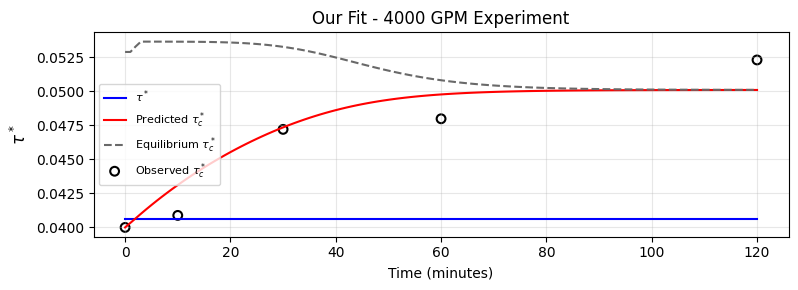

In [9]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_4000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['4000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_4000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_4000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 4000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# export applied tau* and predicted tau_c* for 4000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_4000.csv', index=False)

In [11]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = len(our_pred_at_obs)
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001273448022
Valid comparison points: 5


5000 GPM

In [12]:
tauc_obs_5000 = tauc_measurements_flume['5000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_5000, k_flume_5000, tau_pot_flume_5000, tauc_ratio_5000 = evolve_tauc_tc(
    tau_star_flume['5000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_5000,
)

tauc at time: 1 is 0.04041896411759568 . tau_pot is 0.05079613619263126 and tau/tauc 1.054275460301797 with k 0.03957990934261196
tauc at time: 2 is 0.040838137117103185 . tau_pot is 0.0512204829133512 and tau/tauc 1.0434541095204268 with k 0.03957990934261196
tauc at time: 3 is 0.04125798683719573 . tau_pot is 0.05165709408308276 and tau/tauc 1.0328357068935539 with k 0.03957990934261196
tauc at time: 4 is 0.041678991656316486 . tau_pot is 0.052106709136054086 and tau/tauc 1.0224029014757128 with k 0.03957990934261196
tauc at time: 5 is 0.04210164281250563 . tau_pot is 0.05257013782505496 and tau/tauc 1.0121391744680939 with k 0.03957990934261196
tauc at time: 6 is 0.04252644690631661 . tau_pot is 0.053048267259224104 and tau/tauc 1.0020287397598358 with k 0.03957990934261196
tauc at time: 7 is 0.04295392861826383 . tau_pot is 0.053542069935148984 and tau/tauc 0.9920564514297127 with k 0.03957990934261196
tauc at time: 8 is 0.04336875500522991 . tau_pot is 0.05364344111323357 and tau/

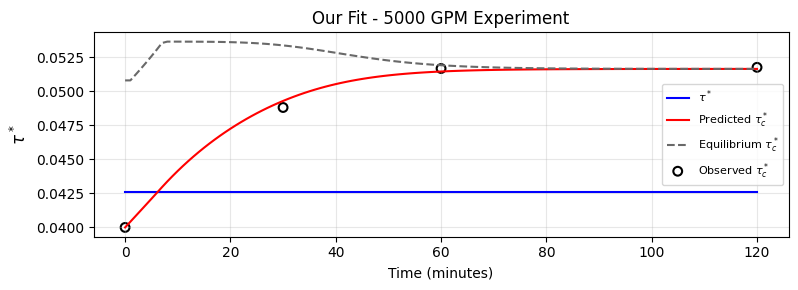

In [13]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_5000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['5000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_5000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_5000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 5000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [14]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.000204557983
Valid comparison points: 4


In [15]:
# export applied tau* and predicted tau_c* for 5000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_5000.csv', index=False)

6000 GPM 

In [16]:
tauc_obs_6000 = tauc_measurements_flume['6000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_6000, k_flume_6000, tau_pot_flume_6000, tauc_ratio_6000 = evolve_tauc_tc(
    tau_star_flume['6000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_6000,
)

tauc at time: 1 is 0.040686256740636605 . tau_pot is 0.047326434216000426 and tau/tauc 1.1630502727653877 with k 0.09835024179492864
tauc at time: 2 is 0.04135281430297734 . tau_pot is 0.04780238375621511 and tau/tauc 1.1443033031150438 with k 0.09835024179492864
tauc at time: 3 is 0.042002226218893116 . tau_pot is 0.048285895465327945 and tau/tauc 1.1266108075651193 with k 0.09835024179492864
tauc at time: 4 is 0.042636870538548206 . tau_pot is 0.04877764944344039 and tau/tauc 1.1098413509785527 with k 0.09835024179492864
tauc at time: 5 is 0.043258979786888536 . tau_pot is 0.04927847012255064 and tau/tauc 1.093880674789801 with k 0.09835024179492864
tauc at time: 6 is 0.04387066831039697 . tau_pot is 0.0497893283616941 and tau/tauc 1.0786287016463236 with k 0.09835024179492864
tauc at time: 7 is 0.044473957606286335 . tau_pot is 0.05031134725433058 and tau/tauc 1.0639971018300236 with k 0.09835024179492864
tauc at time: 8 is 0.045070800185217065 . tau_pot is 0.050845811801536515 and 

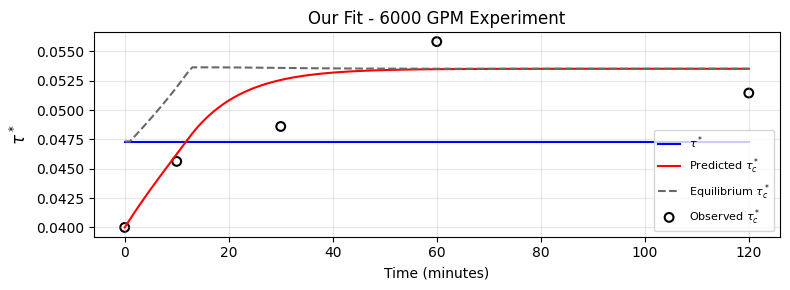

In [17]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_6000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['6000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_6000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_6000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 6000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [18]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001800825516
Valid comparison points: 5


In [19]:
# export applied tau* and predicted tau_c* for 6000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_6000.csv', index=False)

7000 GPM 

In [20]:
tauc_obs_7000 = tauc_measurements_flume['7000'].values
# find min and max of τ*c observations to set bounds for model

tauc_flume_7000, k_flume_7000, tau_pot_flume_7000, tauc_ratio_7000 = evolve_tauc_tc(
    tau_star_flume['7000'],
    dt=1,
    tau_c_min=tauc_min,
    tau_c_max=tauc_max,
    event_indices=tauc_measurements_flume.index,
    tau_c_obs=tauc_obs_7000,
)

tauc at time: 1 is 0.041255841689015804 . tau_pot is 0.04428102895226201 and tau/tauc 1.3262544347645158 with k 0.3472203953348919
tauc at time: 2 is 0.04229546088343766 . tau_pot is 0.04479979146355725 and tau/tauc 1.293655202169128 with k 0.3472203953348919
tauc at time: 3 is 0.0431659177599831 . tau_pot is 0.045262754550131415 and tau/tauc 1.2675681611645042 with k 0.3472203953348919
tauc at time: 4 is 0.04390188894096392 . tau_pot is 0.04567476418654068 and tau/tauc 1.246318650971437 with k 0.3472203953348919
tauc at time: 5 is 0.04452941941874846 . tau_pot is 0.04604107269901212 and tau/tauc 1.2287549156089543 with k 0.3472203953348919
tauc at time: 6 is 0.04506841154987656 . tau_pot is 0.046366785496481655 and tau/tauc 1.2140597176238812 with k 0.3472203953348919
tauc at time: 7 is 0.04553431211365338 . tau_pot is 0.04665661635295716 and tau/tauc 1.2016376323733589 with k 0.3472203953348919
tauc at time: 8 is 0.04593927911058695 . tau_pot is 0.04691480095531773 and tau/tauc 1.191

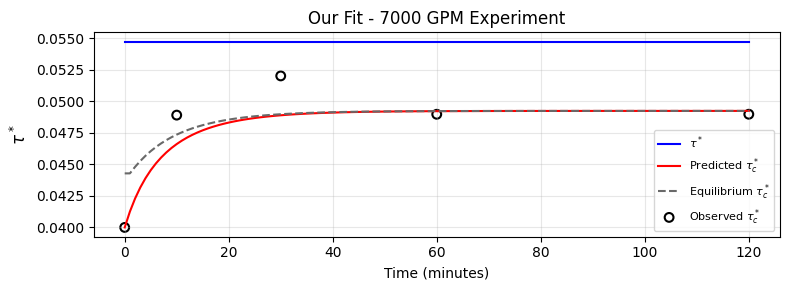

In [21]:
# tau_star is a pd.Series with datetime index
tau_c_pred_series = pd.Series(tauc_flume_7000, index=tau_star_flume.index)
tau_star_series = pd.Series(tau_star_flume['7000'].values, index=tau_star_flume.index)
obs_tauc_series = pd.Series(tauc_obs_7000, index=tauc_measurements_flume.index)
# ockelford fit 
tt = np.linspace(0,120,120)
#ockelford_tauc = tau_eq_flume_7000 - (tau_eq_flume_7000 - tauc_min) * np.exp(-0.488 * tt)

fig, ax = plt.subplots(figsize=(8, 3))

ax.plot(tau_star_series.index, tau_star_series.values, color='blue', label=r'$\tau^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_c_pred_series.values, color='red', label=r'Predicted $\tau_c^*$', linewidth=1.5)
ax.plot(tau_c_pred_series.index, tau_pot_flume_7000, color='dimgrey', linestyle='--', label=r'Equilibrium $\tau_c^*$', linewidth=1.5)
ax.scatter(obs_tauc_series.index, obs_tauc_series.values, facecolors='none', edgecolors='black', s=40, 
        linewidth=1.5, label=r'Observed $\tau_c^*$')

ax.set_ylabel(r'$\tau^*$', fontsize=12)
ax.set_xlabel('Time (minutes)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.title('Our Fit - 7000 GPM Experiment', fontsize=12)
plt.tight_layout()
plt.show()

In [22]:
# calculate MAE between our model and ockelford to the observed τ*c values
# align predictions to the observed τ*c timestamps
our_pred_at_obs = tau_c_pred_series.reindex(obs_tauc_series.index).to_numpy(dtype=float)
obs_vals = obs_tauc_series.to_numpy(dtype=float)

# make Ockelford array comparable in length with observed values
n = min(len(obs_vals), len(our_pred_at_obs))
obs_vals = obs_vals[:n]
our_pred_at_obs = our_pred_at_obs[:n]

# ignore any NaNs before calculating MAE
valid = (~np.isnan(obs_vals) &
         ~np.isnan(our_pred_at_obs))

mae_our = mean_absolute_error(obs_vals[valid], our_pred_at_obs[valid])

print(f"MAE (our model): {mae_our:.12f}")
print(f"Valid comparison points: {valid.sum()}")

MAE (our model): 0.001183925760
Valid comparison points: 5


In [23]:
# export applied tau* and predicted tau_c* for 7000 GPM experiment to csv
output_df = pd.DataFrame({
    'Time': tau_star_series.index, 
    'tau_star': tau_star_series.values,
    'tau_c_star': tau_c_pred_series.values,
})
output_df.to_csv('flume_data/results/tau-tauc/monod_predicted_tauc_7000.csv', index=False)

#### Plot All Together

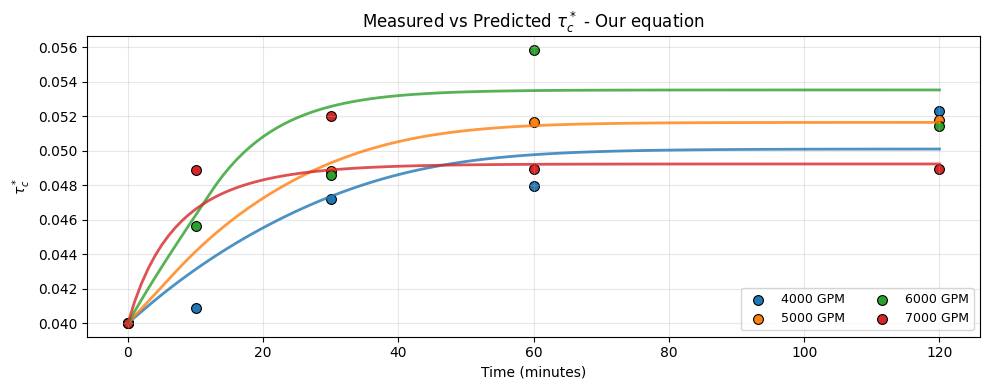

In [24]:
flows = ['4000', '5000', '6000', '7000']
colors = dict(zip(flows, plt.cm.tab10.colors[:4]))

# predicted tau_c* arrays from your evolve_tauc runs
pred_by_flow = {
    '4000': tauc_flume_4000,
    '5000': tauc_flume_5000,
    '6000': tauc_flume_6000,
    '7000': tauc_flume_7000,
}

fig, ax = plt.subplots(figsize=(10, 4))

for flow in flows:
    pred = pred_by_flow.get(flow, None)
    if pred is None:
        continue

    c = colors[flow]

    # time axis from flume tau* table
    time_pred = tau_star_flume.index.to_numpy()
    pred = np.asarray(pred, dtype=float)

    # safety trim in case lengths differ
    n = min(len(time_pred), len(pred))
    ax.plot(
        time_pred[:n],
        pred[:n],
        color=c,
        linewidth=2,
        alpha=0.8
    )

    # observed tau_c* for same flow
    obs_series = tauc_measurements_flume[flow].astype(float)
    valid_obs = ~obs_series.isna()

    ax.scatter(
            obs_series.index[valid_obs],
            obs_series[valid_obs],
            color=c,
            s=50,
            edgecolors='black',
            linewidth=0.8,
            label=f'{flow} GPM'
        )

ax.set_xlabel('Time (minutes)')
ax.set_ylabel(r'$\tau_c^*$')
ax.set_title(r'Measured vs Predicted $\tau_c^*$ - Our equation', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()
